In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/C_student_procrastination_dataset.xlsx")

In [3]:
df.head()

,study_hours_per_day,assignment_delay_days,attendance_percentage,study_consistency_score,daily_screen_time_hours,social_media_hours,gaming_hours_per_week,notifications_per_day,motivation_level,stress_level,overthinking_score,self_discipline_score,sleep_hours,exercise_days_per_week,routine_consistency_score,uses_todo_list,planning_score,avg_task_start_delay_minutes,procrastination_score
0,5.42,1.74,72.49,3.01,5.79,3.65,8.73,84,8.09,4.52,4.74,1.63,5.13,1.26,2.28,0,2.29,104.62,66.64
1,2.69,2.88,59.88,2.52,11.25,7.61,19.94,250,7.99,7.77,8.64,3.49,4.29,1.41,2.44,0,3.74,172.87,100.00
2,3.06,3.18,53.26,1.00,11.51,5.98,10.44,242,10.00,7.41,8.10,2.81,5.56,0.11,1.32,0,1.32,190.77,100.00
3,5.70,1.68,71.58,6.62,7.03,3.66,7.02,160,4.67,5.33,3.28,6.91,7.22,2.89,7.17,1,5.77,100.58,33.78
4,6.03,1.03,84.59,5.71,7.19,4.21,4.26,138,5.33,4.78,6.31,5.15,6.46,2.63,7.29,1,5.83,61.88,47.17


In [20]:
df.head().to_csv("../outputs/dataset_preview.csv", index=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   study_hours_per_day           1000 non-null   float64
 1   assignment_delay_days         1000 non-null   float64
 2   attendance_percentage         1000 non-null   float64
 3   study_consistency_score       1000 non-null   float64
 4   daily_screen_time_hours       1000 non-null   float64
 5   social_media_hours            1000 non-null   float64
 6   gaming_hours_per_week         1000 non-null   float64
 7   notifications_per_day         1000 non-null   int64  
 8   motivation_level              1000 non-null   float64
 9   stress_level                  1000 non-null   float64
 10  overthinking_score            1000 non-null   float64
 11  self_discipline_score         1000 non-null   float64
 12  sleep_hours                   1000 non-null   float64
 13  exer

In [21]:
with open("../outputs/dataset_info.txt", "w") as f:
    df.info(buf=f)

In [5]:
df.describe()

,study_hours_per_day,assignment_delay_days,attendance_percentage,study_consistency_score,daily_screen_time_hours,social_media_hours,gaming_hours_per_week,notifications_per_day,motivation_level,stress_level,overthinking_score,self_discipline_score,sleep_hours,exercise_days_per_week,routine_consistency_score,uses_todo_list,planning_score,avg_task_start_delay_minutes,procrastination_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,5.888300,1.619250,76.239890,5.532480,7.14084,4.140170,8.360790,132.66900,5.453930,5.522750,5.529650,5.526520,5.939630,2.778020,5.474650,0.530000,5.526350,97.154020,49.02953
std,2.528999,1.306822,18.769717,2.524291,2.79943,2.348707,5.558643,61.18769,2.595868,2.171136,2.183553,2.620263,1.409697,1.528738,2.583089,0.499349,2.583513,78.398046,38.36978
min,0.000000,0.000000,40.000000,1.000000,1.00000,0.000000,0.000000,12.00000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000
25%,4.115000,0.500000,61.837500,3.477500,5.13500,2.117500,4.017500,87.00000,3.500000,3.817500,3.877500,3.420000,4.910000,1.637500,3.460000,0.000000,3.457500,30.000000,5.69750
50%,5.975000,1.285000,81.310000,5.485000,6.97500,3.940000,7.410000,123.50000,5.465000,5.485000,5.425000,5.480000,5.995000,2.725000,5.490000,1.000000,5.515000,77.235000,45.89500
75%,7.940000,2.530000,91.465000,7.730000,9.09500,6.000000,11.725000,170.25000,7.425000,7.280000,7.250000,7.717500,6.970000,3.940000,7.630000,1.000000,7.660000,151.722500,100.00000
max,11.480000,5.000000,100.000000,10.000000,13.98000,10.000000,27.840000,300.00000,10.000000,10.000000,10.000000,10.000000,9.820000,7.000000,10.000000,1.000000,10.000000,300.000000,100.00000


In [22]:
df.describe().to_excel(
    "../outputs/dataset_statistics.xlsx"
)

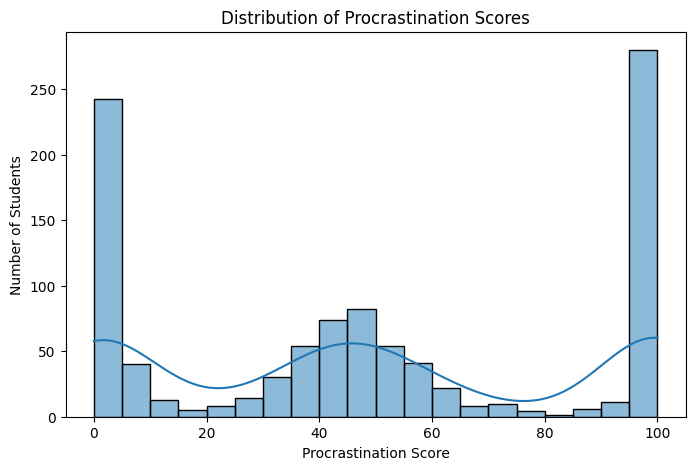

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["procrastination_score"], bins=20, kde=True)

plt.title("Distribution of Procrastination Scores")
plt.xlabel("Procrastination Score")
plt.ylabel("Number of Students")

plt.savefig("../outputs/procrastination_distribution.png")

plt.show()

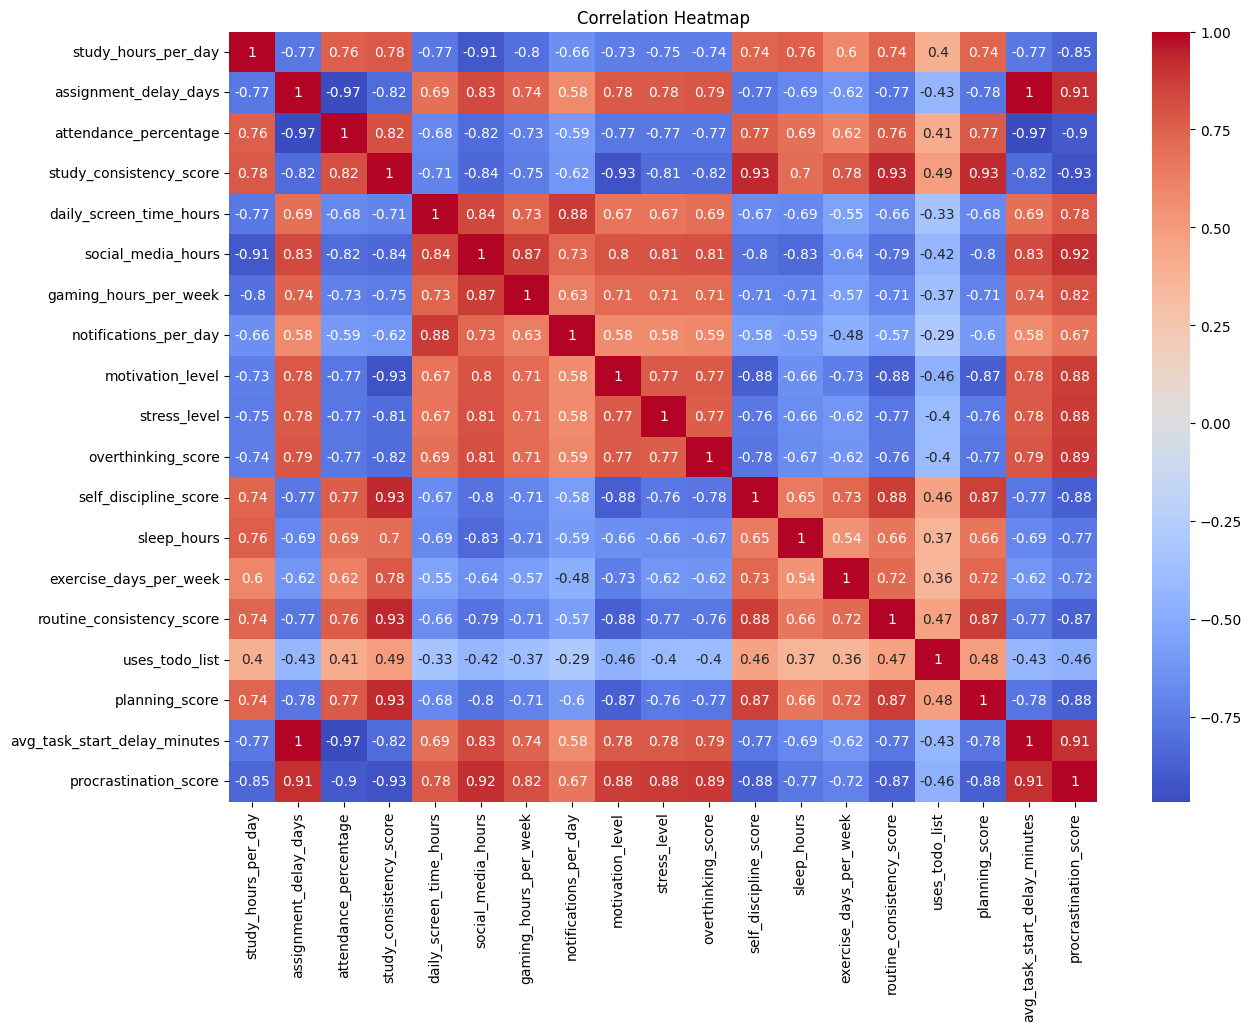

In [24]:
correlation_matrix = df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../outputs/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [8]:
correlation_with_target = df.corr()["procrastination_score"].sort_values(ascending=False)

print(correlation_with_target)

procrastination_score           1.000000
social_media_hours              0.922395
avg_task_start_delay_minutes    0.910668
assignment_delay_days           0.910638
overthinking_score              0.889275
stress_level                    0.881948
motivation_level                0.876833
gaming_hours_per_week           0.816993
daily_screen_time_hours         0.777692
notifications_per_day           0.668725
uses_todo_list                 -0.461477
exercise_days_per_week         -0.715667
sleep_hours                    -0.766060
study_hours_per_day            -0.850101
routine_consistency_score      -0.872154
planning_score                 -0.875879
self_discipline_score          -0.878671
attendance_percentage          -0.897703
study_consistency_score        -0.930140
Name: procrastination_score, dtype: float64


In [9]:
X = df.drop("procrastination_score", axis=1)

y = df["procrastination_score"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = model.predict(X_test)

In [13]:
y_pred[:10]

array([ 40.65503204,  -0.90905548,  97.86411111,   8.34817203,
        96.71422268, 107.24841654,   3.70838894,   7.52368034,
        95.15795099,  11.2591457 ])

In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [15]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.546264912779754
MSE: 30.657109996757978
RMSE: 5.536886308816353
R2 Score: 0.9798663557688229


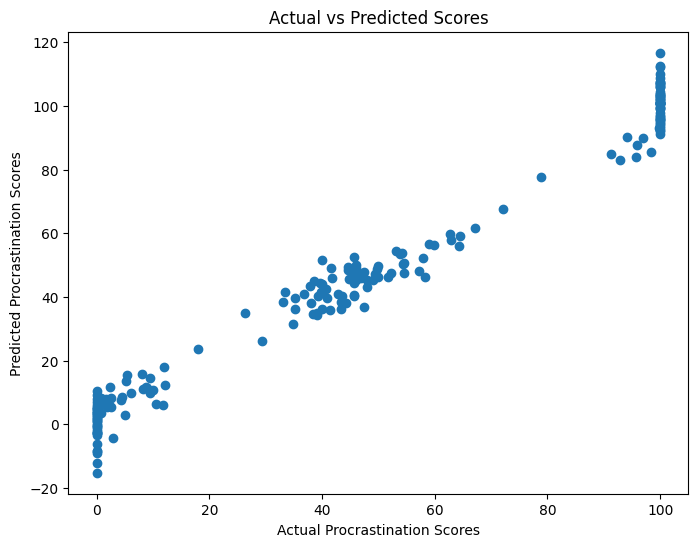

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Procrastination Scores")
plt.ylabel("Predicted Procrastination Scores")

plt.title("Actual vs Predicted Scores")

plt.savefig("../outputs/actual_vs_predicted.png")

plt.show()

In [17]:
new_student = [[
    2.5,   # study_hours_per_day
    4,     # assignment_delay_days
    75,    # attendance_percentage
    4,     # study_consistency_score
    8,     # daily_screen_time_hours
    5,     # social_media_hours
    20,    # gaming_hours_per_week
    120,   # notifications_per_day
    4,     # motivation_level
    8,     # stress_level
    9,     # overthinking_score
    3,     # self_discipline_score
    5,     # sleep_hours
    1,     # exercise_days_per_week
    3,     # routine_consistency_score
    0,     # uses_todo_list
    2,     # planning_score
    90     # avg_task_start_delay_minutes
]]

prediction = model.predict(new_student)

print("Predicted Procrastination Score:", prediction[0])

Predicted Procrastination Score: -2.6978181380070794


c:\Users\badna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
import joblib

joblib.dump(model, "../models/procrastination_model.pkl")

['../models/procrastination_model.pkl']